# Creativity Pair Curvature Analysis

Measure how curved the mood-space interpolation paths are for paired images in the creativity dataset. Higher curvature suggests blends that may be harder but potentially more interesting.

In [1]:
# Core dependencies and project helpers
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

from app import (
    train_mood_space,
    compute_direction_from_two_images,
    load_config,
)
from extract_features import (
    dino_image_transform,
    clip_image_transform,
    extract_dino_features,
    extract_clip_features,
)
from dino_correspondence import (
    kway_cluster_per_image,
    match_centers_two_images,
    get_cluster_center_features,
)

plt.rcParams["figure.dpi"] = 120

## Helper Utilities

Utility functions to find paired images and process embeddings for curvature measurements.

In [2]:
# Helper functions for data loading and path statistics
VALID_IMAGE_SUFFIXES: Tuple[str, ...] = (".png", ".jpg", ".jpeg", ".webp", ".bmp")


def find_image_pairs(
    left_dir: Path,
    right_dir: Path,
    suffixes: Sequence[str] = VALID_IMAGE_SUFFIXES,
) -> Tuple[List[Tuple[str, Path, Path]], List[Path], List[Path]]:
    left_dir = Path(left_dir)
    right_dir = Path(right_dir)

    left_files = sorted(p for p in left_dir.iterdir() if p.suffix.lower() in suffixes)
    right_files = sorted(p for p in right_dir.iterdir() if p.suffix.lower() in suffixes)
    right_lookup: Dict[str, Path] = {p.name: p for p in right_files}

    pairs: List[Tuple[str, Path, Path]] = []
    missing_right: List[Path] = []
    for left_path in left_files:
        partner = right_lookup.get(left_path.name)
        if partner is None:
            missing_right.append(left_path)
            continue
        pairs.append((left_path.stem, left_path, partner))

    left_names = {p.name for p in left_files}
    missing_left = [p for p in right_files if p.name not in left_names]
    return pairs, missing_right, missing_left


def load_rgb_image(path: Path, size: Tuple[int, int] = (512, 512)) -> Image.Image:
    with Image.open(path) as img:
        converted = img.convert("RGB")
        if size is not None:
            converted = converted.resize(size, Image.Resampling.LANCZOS)
        return converted


def _flatten_embeddings(tensor: torch.Tensor) -> np.ndarray:
    return tensor.reshape(tensor.shape[0], -1).cpu().numpy()


def _downsample_cluster_labels(cluster_labels: torch.Tensor, downsample_factor: int = 2) -> torch.Tensor:
    cls_token = cluster_labels[:1]
    spatial_labels = cluster_labels[1:]
    spatial_size = int(spatial_labels.shape[0] ** 0.5)
    if spatial_size * spatial_size != spatial_labels.shape[0]:
        raise ValueError("Spatial portion of cluster labels must form a square grid")
    if spatial_size % downsample_factor != 0:
        raise ValueError("Downsample factor must evenly divide spatial grid size")
    spatial_grid = spatial_labels.reshape(spatial_size, spatial_size)
    new_size = spatial_size // downsample_factor
    pooled = []
    for i in range(new_size):
        for j in range(new_size):
            patch = spatial_grid[
                i * downsample_factor:(i + 1) * downsample_factor,
                j * downsample_factor:(j + 1) * downsample_factor,
            ]
            pooled.append(torch.mode(patch.flatten(), keepdim=False).values)
    pooled = torch.stack(pooled)
    return torch.cat([cls_token, pooled])


def _build_direction_field(direction_vectors: torch.Tensor, cluster_labels: torch.Tensor) -> torch.Tensor:
    cluster_labels = cluster_labels.long()
    return direction_vectors[cluster_labels]


def _segment_lengths(flat_embeddings: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    diffs = np.diff(flat_embeddings, axis=0)
    lengths = np.linalg.norm(diffs, axis=1)
    return diffs, lengths


def _direction_changes(diffs: np.ndarray, lengths: np.ndarray) -> np.ndarray:
    if len(diffs) < 2:
        return np.array([])
    eps = 1e-12
    norm_dirs = diffs / np.clip(lengths[:, None], eps, None)
    dot_products = np.sum(norm_dirs[:-1] * norm_dirs[1:], axis=1)
    dot_products = np.clip(dot_products, -1.0, 1.0)
    return np.degrees(np.arccos(dot_products))


def _compute_path_statistics(
    mood_flat: np.ndarray,
    clip_flat: np.ndarray,
    interpolation_weights: Sequence[float],
) -> Dict[str, float]:
    mood_diffs, mood_lengths = _segment_lengths(mood_flat)
    clip_diffs, clip_lengths = _segment_lengths(clip_flat)

    total_length_mood = float(mood_lengths.sum())
    total_length_clip = float(clip_lengths.sum())
    length_ratio = total_length_mood / total_length_clip if total_length_clip > 0 else float("nan")

    mood_direction_changes = _direction_changes(mood_diffs, mood_lengths)
    clip_direction_changes = _direction_changes(clip_diffs, clip_lengths)

    cumulative_mood = np.concatenate(([0.0], np.cumsum(mood_lengths)))
    cumulative_clip = np.concatenate(([0.0], np.cumsum(clip_lengths)))

    stats = {
        "mood_total_length": total_length_mood,
        "clip_total_length": total_length_clip,
        "length_ratio": length_ratio,
        "mood_mean_direction_change": float(mood_direction_changes.mean()) if len(mood_direction_changes) > 0 else float("nan"),
        "mood_max_direction_change": float(mood_direction_changes.max()) if len(mood_direction_changes) > 0 else float("nan"),
        "mood_direction_change_sum": float(mood_direction_changes.sum()) if len(mood_direction_changes) > 0 else float("nan"),
        "mood_direction_change_std": float(mood_direction_changes.std(ddof=0)) if len(mood_direction_changes) > 0 else float("nan"),
        "clip_mean_direction_change": float(clip_direction_changes.mean()) if len(clip_direction_changes) > 0 else float("nan"),
        "clip_max_direction_change": float(clip_direction_changes.max()) if len(clip_direction_changes) > 0 else float("nan"),
        "clip_direction_change_sum": float(clip_direction_changes.sum()) if len(clip_direction_changes) > 0 else float("nan"),
        "num_segments": int(len(mood_lengths)),
        "interpolation_steps": int(len(interpolation_weights)),
        "mood_cumulative_lengths": cumulative_mood,
        "clip_cumulative_lengths": cumulative_clip,
        "mood_direction_profile": mood_direction_changes,
        "clip_direction_profile": clip_direction_changes,
    }
    return stats


def standardize_series(series: pd.Series) -> pd.Series:
    valid = series.replace([np.inf, -np.inf], np.nan).dropna()
    if valid.empty:
        return pd.Series(np.zeros(len(series)), index=series.index)
    std = valid.std(ddof=0)
    if std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    mean = valid.mean()
    return (series - mean) / std

## Load Creativity Pairs

Match files across the left and right directories and report any missing partners.

In [3]:
# Identify matched pairs in the creativity dataset
LEFT_DIR = Path("./images/creativity/left")
RIGHT_DIR = Path("./images/creativity/right")

pairs, missing_right, missing_left = find_image_pairs(LEFT_DIR, RIGHT_DIR)

print(f"Found {len(pairs)} matched pairs.")
if missing_right:
    print(f"Left images without match ({len(missing_right)}): {[p.name for p in missing_right]}")
if missing_left:
    print(f"Right images without match ({len(missing_left)}): {[p.name for p in missing_left]}")

pair_preview = pd.DataFrame(
    [(name, str(left), str(right)) for name, left, right in pairs],
    columns=["pair", "left_path", "right_path"],
)
pair_preview.head()

Found 44 matched pairs.


,pair,left_path,right_path
0,00031,images/creativity/left/00031.jpg,images/creativity/right/00031.jpg
1,00173,images/creativity/left/00173.jpg,images/creativity/right/00173.jpg
2,00436,images/creativity/left/00436.jpg,images/creativity/right/00436.jpg
3,00478,images/creativity/left/00478.jpg,images/creativity/right/00478.jpg
4,00482,images/creativity/left/00482.jpg,images/creativity/right/00482.jpg


## Configure Analysis

Choose training hyperparameters, interpolation density, and clustering options for curvature measurement.

In [4]:
# Analysis configuration
CONFIG_PATH = "./config.yaml"
IMAGE_SIZE = (512, 512)
INTERPOLATION_WEIGHTS = np.linspace(0.0, 1.0, 21).tolist()
N_CLUSTERS = 10
DOWNSAMPLE_FACTOR = 2
USE_CLUSTER_CORRESPONDENCE = False  # Set False to compare direct token interpolation
MAX_PAIRS = None  # Set to an integer to subsample pairs while iterating

TRAINING_KWARGS = {
    "learning_rate": 1e-3,
    "training_steps": 1000,
    "mlp_width": 512,
    "mlp_layers": 2,
    "config_path": CONFIG_PATH,
}

print("CUDA available:", torch.cuda.is_available())
print("Interpolation steps:", len(INTERPOLATION_WEIGHTS))
print("Using cluster correspondence:", USE_CLUSTER_CORRESPONDENCE)

CUDA available: True
Interpolation steps: 21
Using cluster correspondence: False


In [5]:
# Core analysis functions

def compute_curvature_statistics(
    model: torch.nn.Module,
    image_a: Image.Image,
    image_b: Image.Image,
    config_path: str,
    interpolation_weights: Sequence[float],
    n_clusters: int,
    downsample_factor: int,
    use_cluster_correspondence: bool,
) -> Dict[str, object]:
    model.eval()
    with torch.no_grad():
        config = load_config(config_path)
        clip_inputs = torch.stack([clip_image_transform(img) for img in [image_a, image_b]])
        dino_inputs = torch.stack([dino_image_transform(img) for img in [image_a, image_b]])
        dino_embeds = extract_dino_features(dino_inputs)
        clip_embeds = extract_clip_features(clip_inputs, ipadapter_version=config.ipadapter_version)

        model_device = next(model.parameters()).device
        dino_embeds_device = dino_embeds.to(model_device)

        compressed_embeds = model.encoder(dino_embeds_device)

        if use_cluster_correspondence:
            cluster_eigvecs = kway_cluster_per_image(dino_embeds_device, n_clusters=n_clusters, gamma=None)
            cluster_mapping = match_centers_two_images(
                dino_embeds_device[0].cpu(),
                dino_embeds_device[1].cpu(),
                cluster_eigvecs[0].cpu(),
                cluster_eigvecs[1].cpu(),
                match_method="hungarian",
            )
            cluster_mapping = np.asarray(cluster_mapping)

            mood_direction_vectors = compute_direction_from_two_images(
                compressed_embeds,
                cluster_eigvecs,
                cluster_mapping,
                use_unit_norm=False,
                return_direction_vectors=True,
            )

            cluster_labels_a = cluster_eigvecs[0].argmax(-1)
            mood_direction_field = _build_direction_field(mood_direction_vectors, cluster_labels_a)

            cluster_labels_a_cpu = cluster_labels_a.cpu()
            cluster_labels_b_cpu = cluster_eigvecs[1].argmax(-1).cpu()
            cluster_labels_a_clip = _downsample_cluster_labels(cluster_labels_a_cpu, downsample_factor=downsample_factor)
            cluster_labels_b_clip = _downsample_cluster_labels(cluster_labels_b_cpu, downsample_factor=downsample_factor)

            clip_centers_a = get_cluster_center_features(clip_embeds[0], cluster_labels_a_clip, cluster_eigvecs.shape[-1])
            clip_centers_b = get_cluster_center_features(clip_embeds[1], cluster_labels_b_clip, cluster_eigvecs.shape[-1])
            clip_direction_vectors = []
            for idx_a, idx_b in enumerate(cluster_mapping):
                direction = clip_centers_b[idx_b] - clip_centers_a[idx_a]
                clip_direction_vectors.append(direction)
            clip_direction_vectors = torch.stack(clip_direction_vectors)
            clip_direction_field = _build_direction_field(clip_direction_vectors, cluster_labels_a_clip)
        else:
            cluster_eigvecs = None  # Clarify unused in direct interpolation mode
            mood_direction_field = compressed_embeds[1] - compressed_embeds[0]
            clip_direction_field = clip_embeds[1] - clip_embeds[0]

        mood_path_tensors = []
        clip_path_tensors = []
        for weight in interpolation_weights:
            interpolated_compressed = compressed_embeds[0] + mood_direction_field * weight
            decoded_clip = model.decoder(interpolated_compressed)
            mood_path_tensors.append(decoded_clip.detach().cpu())

            interpolated_clip = clip_embeds[0] + clip_direction_field * weight
            clip_path_tensors.append(interpolated_clip.detach().cpu())

    mood_flat = _flatten_embeddings(torch.stack(mood_path_tensors))
    clip_flat = _flatten_embeddings(torch.stack(clip_path_tensors))
    stats = _compute_path_statistics(mood_flat, clip_flat, interpolation_weights)
    stats["use_cluster_correspondence"] = use_cluster_correspondence
    return stats


def analyze_pair(
    pair_id: str,
    left_path: Path,
    right_path: Path,
    image_size: Tuple[int, int],
    training_kwargs: Dict[str, object],
    interpolation_weights: Sequence[float],
    n_clusters: int,
    downsample_factor: int,
    use_cluster_correspondence: bool,
) -> Dict[str, object]:
    training_kwargs = dict(training_kwargs)  # copy to avoid side-effects
    img_left = load_rgb_image(left_path, size=image_size)
    img_right = load_rgb_image(right_path, size=image_size)

    model, _ = train_mood_space(
        pil_images=[img_left, img_right],
        **training_kwargs,
    )

    stats = compute_curvature_statistics(
        model=model,
        image_a=img_left,
        image_b=img_right,
        config_path=training_kwargs.get("config_path", CONFIG_PATH),
        interpolation_weights=interpolation_weights,
        n_clusters=n_clusters,
        downsample_factor=downsample_factor,
        use_cluster_correspondence=use_cluster_correspondence,
    )

    stats.update(
        {
            "pair": pair_id,
            "left_path": str(left_path),
            "right_path": str(right_path),
            "training_steps": training_kwargs.get("training_steps"),
        }
    )

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return stats

In [6]:
# Execute curvature analysis over all matched pairs
analysis_results: List[Dict[str, object]] = []
analysis_failures: List[Dict[str, object]] = []

pair_subset = pairs if MAX_PAIRS is None else pairs[:MAX_PAIRS]
print(f"Analyzing {len(pair_subset)} pairs (MAX_PAIRS={MAX_PAIRS}).")

for idx, (pair_id, left_path, right_path) in enumerate(pair_subset, start=1):
    print(f"[{idx}/{len(pair_subset)}] {pair_id}")
    try:
        stats = analyze_pair(
            pair_id=pair_id,
            left_path=left_path,
            right_path=right_path,
            image_size=IMAGE_SIZE,
            training_kwargs=TRAINING_KWARGS,
            interpolation_weights=INTERPOLATION_WEIGHTS,
            n_clusters=N_CLUSTERS,
            downsample_factor=DOWNSAMPLE_FACTOR,
            use_cluster_correspondence=USE_CLUSTER_CORRESPONDENCE,
        )
        analysis_results.append(stats)
    except Exception as exc:
        print(f"  Failed: {exc}")
        analysis_failures.append(
            {
                "pair": pair_id,
                "left_path": str(left_path),
                "right_path": str(right_path),
                "error": str(exc),
            }
        )

print(f"Completed {len(analysis_results)} successful analyses.")
if analysis_failures:
    print(f"Encountered {len(analysis_failures)} failures; details captured in analysis_failures dataframe.")

Analyzing 44 pairs (MAX_PAIRS=None).
[1/44] 00031


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Training: |          | 0/? [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Completed 44 successful analyses.


In [7]:
# Consolidate statistics and compute rankings
if not analysis_results:
    analysis_df = pd.DataFrame()
    print("No successful analyses recorded. Rerun the previous cell after verifying training completed.")
else:
    analysis_df = pd.DataFrame(analysis_results)

    # Define which metrics contribute to path score
    score_columns = [
        "length_ratio",                    # How much longer is mood-space path vs linear
        "mood_mean_direction_change",      # Average curvature per step
    ]

    # Standardize each metric to z-scores for fair comparison
    for col in score_columns:
        analysis_df[f"z_{col}"] = standardize_series(analysis_df[col])

    # Composite path score = sum of standardized metrics
    analysis_df["path_score"] = analysis_df[[f"z_{col}" for col in score_columns]].sum(axis=1)
    
    # Create ranking columns
    analysis_df["rank_path_score"] = (
        analysis_df["path_score"].rank(method="dense", ascending=False).astype(int)
    )
    analysis_df["rank_length_ratio"] = (
        analysis_df["length_ratio"].rank(method="dense", ascending=False).astype(int)
    )
    analysis_df["rank_mood_mean_direction"] = (
        analysis_df["mood_mean_direction_change"].rank(method="dense", ascending=False).astype(int)
    )
    analysis_df["rank_mood_direction_sum"] = (
        analysis_df["mood_direction_change_sum"].rank(method="dense", ascending=False).astype(int)
    )

    display_columns = [
        "rank_path_score",
        "pair",
        "path_score",
        "length_ratio",
        "mood_mean_direction_change",
        "mood_direction_change_sum",
        "mood_total_length",
        "clip_total_length",
    ]

if analysis_failures:
    failures_df = pd.DataFrame(analysis_failures)
    print("\nFailed analyses:")
    display(failures_df)

## Results & Rankings

**Understanding the Statistics:**

- **`length_ratio`**: Ratio of mood-space path length to clip-space path length. Higher values indicate the mood-space interpolation takes a longer, more curved route compared to a straight line in CLIP space. Values > 1.0 suggest non-linear blending.

- **`mood_mean_direction_change`**: Average angle (in degrees) between consecutive direction vectors along the mood-space path. Higher values indicate more curvature/turning.

- **`mood_direction_change_sum`**: Total cumulative turning angle across all path segments. This captures overall path complexity—higher values mean more tortuous paths.

- **`mood_max_direction_change`**: Maximum single-step direction change. Identifies sharp turns or discontinuities in the interpolation.

- **`mood_total_length`**: Total Euclidean distance traveled in mood space during interpolation.

- **`clip_total_length`**: Total Euclidean distance traveled in CLIP space during linear interpolation (baseline).

**Path Score Calculation:**

The composite `path_score` is computed by:
1. Z-score normalizing two key metrics: `length_ratio` and `mood_mean_direction_change`
2. Summing these standardized values to create a single score

Higher path scores suggest image pairs where the mood-space path is significantly more curved and complex than a simple linear blend. These pairs represent potentially more challenging but creatively interesting blends.

In [8]:
# Display comprehensive rankings table
if not analysis_results:
    print("No results to display.")
else:
    print("\n" + "="*80)
    print("PATH SCORE ANALYSIS")
    print("="*80)
    print(f"\nAnalyzed {len(analysis_results)} image pairs")
    print("\nTop 10 pairs ranked by composite path score:")
    print("-"*80)
    
    top_10 = analysis_df.sort_values("rank_path_score")[display_columns].head(10)
    display(top_10)


PATH SCORE ANALYSIS

Analyzed 44 image pairs

Top 10 pairs ranked by composite path score:
--------------------------------------------------------------------------------


,rank_path_score,pair,path_score,length_ratio,mood_mean_direction_change,mood_direction_change_sum,mood_total_length,clip_total_length
36,1,05358,6.270566,2.451687,27.160686,516.053040,850.801697,347.027100
0,2,00031,5.782116,2.397439,26.422482,502.027161,915.352600,381.804260
1,3,00173,4.183079,2.144175,25.094374,476.793091,782.434692,364.911713
14,4,01933,3.363202,2.065366,23.679132,449.903534,727.966858,352.463928
29,5,04371,2.958995,2.015157,23.144732,439.749908,706.983459,350.832886
24,6,03142,2.921598,2.099047,21.821772,414.613647,773.989746,368.733887
10,7,01547,1.937753,1.899986,21.626522,410.903931,696.464417,366.562988
34,8,05078,1.328983,1.844339,20.534391,390.153442,662.592041,359.257141
30,9,04398,0.943442,1.816043,19.742826,375.113708,689.260559,379.539764
23,10,02817,0.835157,1.825979,19.263262,366.001984,702.268005,384.598022


In [ ]:
# save analysis_df to CSV
#analysis_df.to_csv("./images/creativity/metric_no_corr_results.csv", index=False)

## Visual Analysis

Examine the interpolation path characteristics for the top-ranked pair. The plots show:

- **Left plot**: Cumulative arc length as interpolation progresses. Mood-space (curved) vs CLIP (linear baseline).
- **Right plot**: Direction changes at each step. Peaks indicate sharp turns in the interpolation path.

Top-ranked pair: 05358
Left: images/creativity/left/05358.jpg
Right: images/creativity/right/05358.jpg


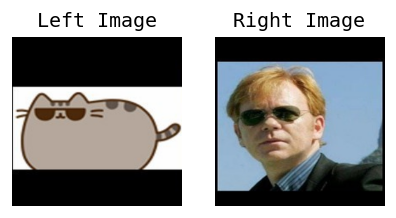

Top-ranked pair: 00031
Left: images/creativity/left/00031.jpg
Right: images/creativity/right/00031.jpg


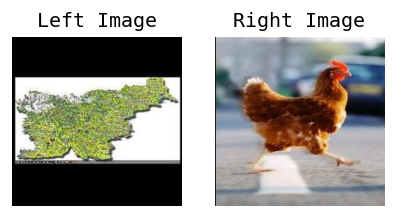

Top-ranked pair: 00173
Left: images/creativity/left/00173.jpg
Right: images/creativity/right/00173.jpg


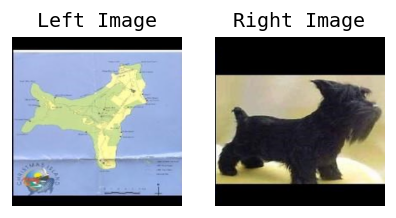

Top-ranked pair: 01933
Left: images/creativity/left/01933.jpg
Right: images/creativity/right/01933.jpg


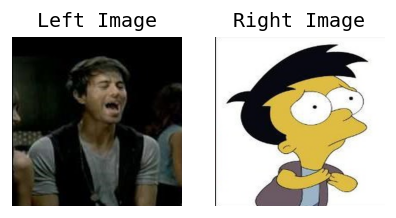

Top-ranked pair: 04371
Left: images/creativity/left/04371.jpg
Right: images/creativity/right/04371.jpg


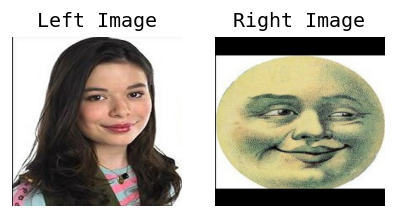

Lowest-ranked pair: 05698
Left: images/creativity/left/05698.jpg
Right: images/creativity/right/05698.jpg


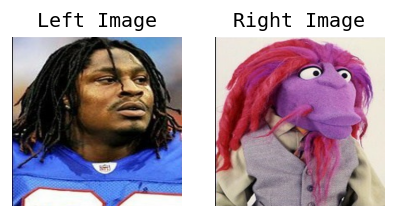

Lowest-ranked pair: 05989
Left: images/creativity/left/05989.jpg
Right: images/creativity/right/05989.jpg


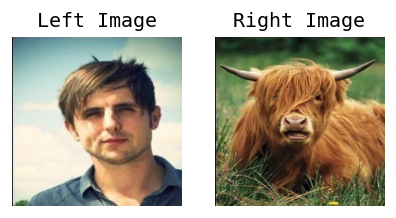

Lowest-ranked pair: 02482
Left: images/creativity/left/02482.jpg
Right: images/creativity/right/02482.jpg


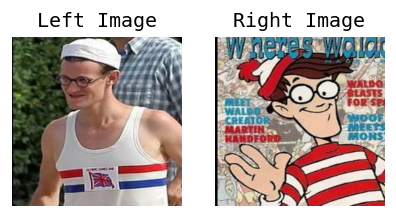

Lowest-ranked pair: 05356
Left: images/creativity/left/05356.jpg
Right: images/creativity/right/05356.jpg


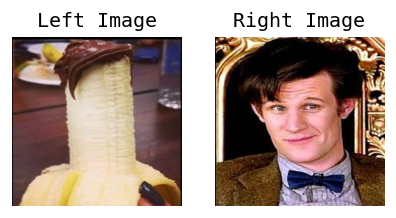

Lowest-ranked pair: 00436
Left: images/creativity/left/00436.jpg
Right: images/creativity/right/00436.jpg


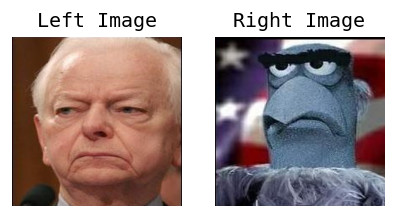

In [11]:
# Preview the highest-ranked pairs
for i in range(5):
    if analysis_results:
        top_entry = analysis_df.sort_values("rank_path_score").iloc[i]
        print(f"Top-ranked pair: {top_entry['pair']}")
        print(f"Left: {top_entry['left_path']}")
        print(f"Right: {top_entry['right_path']}")

        # Display the images side by side
        fig, axes = plt.subplots(1, 2, figsize=(4, 2))
        axes[0].imshow(load_rgb_image(Path(top_entry["left_path"]), size=IMAGE_SIZE))
        axes[0].set_title("Left Image")
        axes[0].axis("off")

        axes[1].imshow(load_rgb_image(Path(top_entry["right_path"]), size=IMAGE_SIZE))
        axes[1].set_title("Right Image")
        axes[1].axis("off")

        plt.show()
    else:
        print("No analysis results available yet.")

# Preview lowest ranked pairs
for i in range(5):
    if analysis_results:
        bottom_entry = analysis_df.sort_values("rank_path_score").iloc[-(i+1)]
        print(f"Lowest-ranked pair: {bottom_entry['pair']}")
        print(f"Left: {bottom_entry['left_path']}")
        print(f"Right: {bottom_entry['right_path']}")

        # Display the images side by side
        fig, axes = plt.subplots(1, 2, figsize=(4, 2))
        axes[0].imshow(load_rgb_image(Path(bottom_entry["left_path"]), size=IMAGE_SIZE))
        axes[0].set_title("Left Image")
        axes[0].axis("off")

        axes[1].imshow(load_rgb_image(Path(bottom_entry["right_path"]), size=IMAGE_SIZE))
        axes[1].set_title("Right Image")
        axes[1].axis("off")

        plt.show()
    else:
        print("No analysis results available yet.")

## Statistical Overview Across All Pairs

Comprehensive visualization of curvature metrics and path scores across the entire dataset.

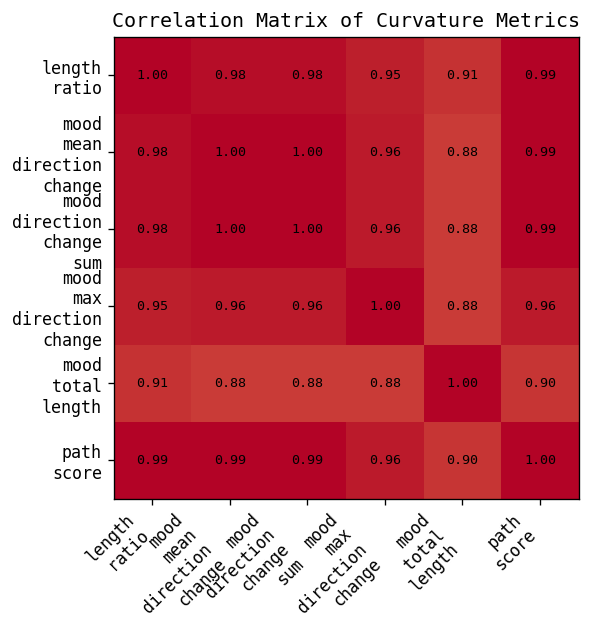

In [12]:
# Correlation analysis between metrics
if analysis_results:
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))
    
    # Correlation heatmap
    correlation_cols = ['length_ratio', 'mood_mean_direction_change', 
                        'mood_direction_change_sum', 'mood_max_direction_change',
                        'mood_total_length', 'path_score']
    corr_matrix = analysis_df[correlation_cols].corr()
    
    im = axes.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes.set_xticks(range(len(correlation_cols)))
    axes.set_yticks(range(len(correlation_cols)))
    axes.set_xticklabels([col.replace('_', '\n') for col in correlation_cols], rotation=45, ha='right')
    axes.set_yticklabels([col.replace('_', '\n') for col in correlation_cols])
    axes.set_title('Correlation Matrix of Curvature Metrics')
    
    # Add correlation values as text
    for i in range(len(correlation_cols)):
        for j in range(len(correlation_cols)):
            text = axes.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                               ha="center", va="center", color="black", fontsize=8)
else:
    print("No analysis results available yet.")